I tried to do it in a way, that only data_name,ground_truth_repeat, cte_repeat  can be changed in order to get visualizations for this dataset. 

In [1]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap

np.random.seed(0)

ground_truth_repeat = 3
cte_repeat = 10


data_name = 'compas'
shap_values_cte_path = f'../metadata/{data_name}/cte_shap_sage_results_0_{cte_repeat}.npy'
times_cte_info_path = f'../metadata/{data_name}/cte_shap_sage_times_0_{cte_repeat}.csv'

shap_values_gt_path = f'../metadata/{data_name}/ground_truth_shap_sage_results_0_{ground_truth_repeat}.npy'
times_gt_info_path = f'../metadata/{data_name}/ground_truth_shap_sage_times_0_{ground_truth_repeat}.csv'

### load calculated shap and sage explanations data for 'ann' model

In [2]:
shap_values_cte = np.load(shap_values_cte_path, allow_pickle=True).item()
times_cte_info = pd.read_csv(times_cte_info_path)

###  load calculated "ground truth"

In [3]:
shap_values_gt = np.load(shap_values_gt_path, allow_pickle=True).item()
times_gt_info = pd.read_csv(times_gt_info_path)

In [4]:
shap_values_gt.items()

dict_items([('ground_truth_sage_kernel', [array([-0.07401391, -0.00758762, -0.0939566 , -0.06068192, -0.00369944,
       -0.00833254,  0.00263617]), array([-0.07618553, -0.0057495 , -0.09574544, -0.06029016, -0.00218899,
       -0.00235945, -0.00311681]), array([-7.37511986e-02, -8.93443387e-03, -9.37940392e-02, -5.89692804e-02,
       -9.97828393e-05, -6.61981201e-03, -3.46732025e-03])]), ('ground_truth_sage_permutation', [array([-0.0775595 , -0.00745223, -0.09318736, -0.06204143, -0.00414693,
       -0.00329746,  0.00021488]), array([-0.07519371, -0.00780234, -0.09705611, -0.06015496, -0.00447454,
       -0.00308398,  0.00080512]), array([-0.07371308, -0.00862816, -0.09457851, -0.0608881 , -0.00446307,
       -0.00283477,  0.00088757])]), ('ground_truth_shap_kernel', [array([[-8.72860927e-02, -1.57632383e-02, -7.64906966e-01, ...,
        -5.64660120e-03,  5.93749815e-04, -1.43111853e-02],
       [ 3.17436113e-02,  1.18729737e-02,  4.27391813e-02, ...,
        -1.17139213e-03, -1.250

In [5]:
shap_values_gt_ = {}

shap_values_gt_['ground_truth_sage_kernel'] = np.mean(
    np.array([shap_values_gt['ground_truth_sage_kernel'][i] for i in range(ground_truth_repeat)]),
    axis=0
)
shap_values_gt_['ground_truth_sage_permutation'] = np.mean(
    np.array([shap_values_gt['ground_truth_sage_permutation'][i] for i in range(ground_truth_repeat)]),
    axis=0
)
shap_values_gt_['ground_truth_shap_kernel'] = np.mean(
    np.array([shap_values_gt['ground_truth_shap_kernel'][i] for i in range(ground_truth_repeat)]),
    axis=0
)
shap_values_gt_['ground_truth_shap_permutation'] = np.mean(
    np.array([shap_values_gt['ground_truth_shap_permutation'][i] for i in range(ground_truth_repeat)]),
    axis=0
)
shap_values_gt=shap_values_gt_

### barplot MAE 

In [6]:
def metric_mae(x, y):
    return np.mean(np.abs(x-y))

In [7]:
columns = [ 'method', 'estimator', 'explanation', 'mae']
results = pd.DataFrame(columns=columns)

shap kernel

In [8]:
shap_values_gt_ = shap_values_gt['ground_truth_shap_kernel']
methods = ['cte_shap_kernel', 'cte_with_predictions_shap_kernel', 'cte_stratified_shap_kernel']

for method in methods:
    shap_values_cte_ = shap_values_cte[method]
    
    for i in shap_values_cte_:
        mae = metric_mae(i, shap_values_gt_)

        if method == 'cte_shap_kernel':
            method = 'cte'
        elif method == 'cte_with_predictions_shap_kernel':
            method = 'cte_predictions'
        elif method == 'cte_stratified_shap_kernel':
            method = 'cte_stratified'

        results = pd.concat([results, pd.DataFrame([[method, 'kernel', 'shap', mae]], columns=columns)], ignore_index=True)

shap permutation

In [9]:
shap_values_gt_ = shap_values_gt['ground_truth_shap_permutation']
methods = ['cte_shap_permutation', 'cte_with_predictions_shap_permutation', 'cte_stratified_shap_permutation']
for method in methods:
    shap_values_cte_ = shap_values_cte[method]

    for i in shap_values_cte_:
        mae = metric_mae(i, shap_values_gt_)

        if method == 'cte_shap_permutation':
            method = 'cte'
        elif method == 'cte_with_predictions_shap_permutation':
            method = 'cte_predictions'
        elif method == 'cte_stratified_shap_permutation':
            method = 'cte_stratified'
            
        results = pd.concat([results, pd.DataFrame([[method, 'permutation', 'shap', mae]], columns=columns)], ignore_index=True)

sage kernel

In [10]:
shap_values_gt_ = shap_values_gt['ground_truth_sage_kernel']
methods = ['cte_sage_kernel', 'cte_with_predictions_sage_kernel', 'cte_stratified_sage_kernel']
for method in methods:
    shap_values_cte_ = shap_values_cte[method]
    
    for i in shap_values_cte_:
        mae = metric_mae(i, shap_values_gt_)

        if method == 'cte_sage_kernel':
            method = 'cte'
        elif method == 'cte_with_predictions_sage_kernel':
            method = 'cte_predictions'
        elif method == 'cte_stratified_sage_kernel':
            method = 'cte_stratified'

        results = pd.concat([results, pd.DataFrame([[method, 'kernel', 'sage', mae]], columns=columns)], ignore_index=True)

sage permutation

In [11]:
shap_values_gt_ = shap_values_gt['ground_truth_sage_permutation']
methods = ['cte_sage_permutation', 'cte_with_predictions_sage_permutation', 'cte_stratified_sage_permutation']
for method in methods:
    shap_values_cte_ = shap_values_cte[method]

    for i in shap_values_cte_:
        mae = metric_mae(i, shap_values_gt_)
    
        if method == 'cte_sage_permutation':
            method = 'cte'
        elif method == 'cte_with_predictions_sage_permutation':
            method = 'cte_predictions'
        elif method == 'cte_stratified_sage_permutation':
            method = 'cte_stratified'

        results = pd.concat([results, pd.DataFrame([[method, 'permutation', 'sage', mae]], columns=columns)], ignore_index=True)

In [12]:
results

,method,estimator,explanation,mae
0,cte,kernel,shap,0.003135
1,cte,kernel,shap,0.003852
2,cte,kernel,shap,0.003712
3,cte,kernel,shap,0.006471
4,cte,kernel,shap,0.002633
...,...,...,...,...
115,cte_stratified,permutation,sage,0.004652
116,cte_stratified,permutation,sage,0.014971
117,cte_stratified,permutation,sage,0.011631
118,cte_stratified,permutation,sage,0.022279


In [13]:
results['exp_est'] = results['estimator'].str.capitalize() + results['explanation'].str.upper()


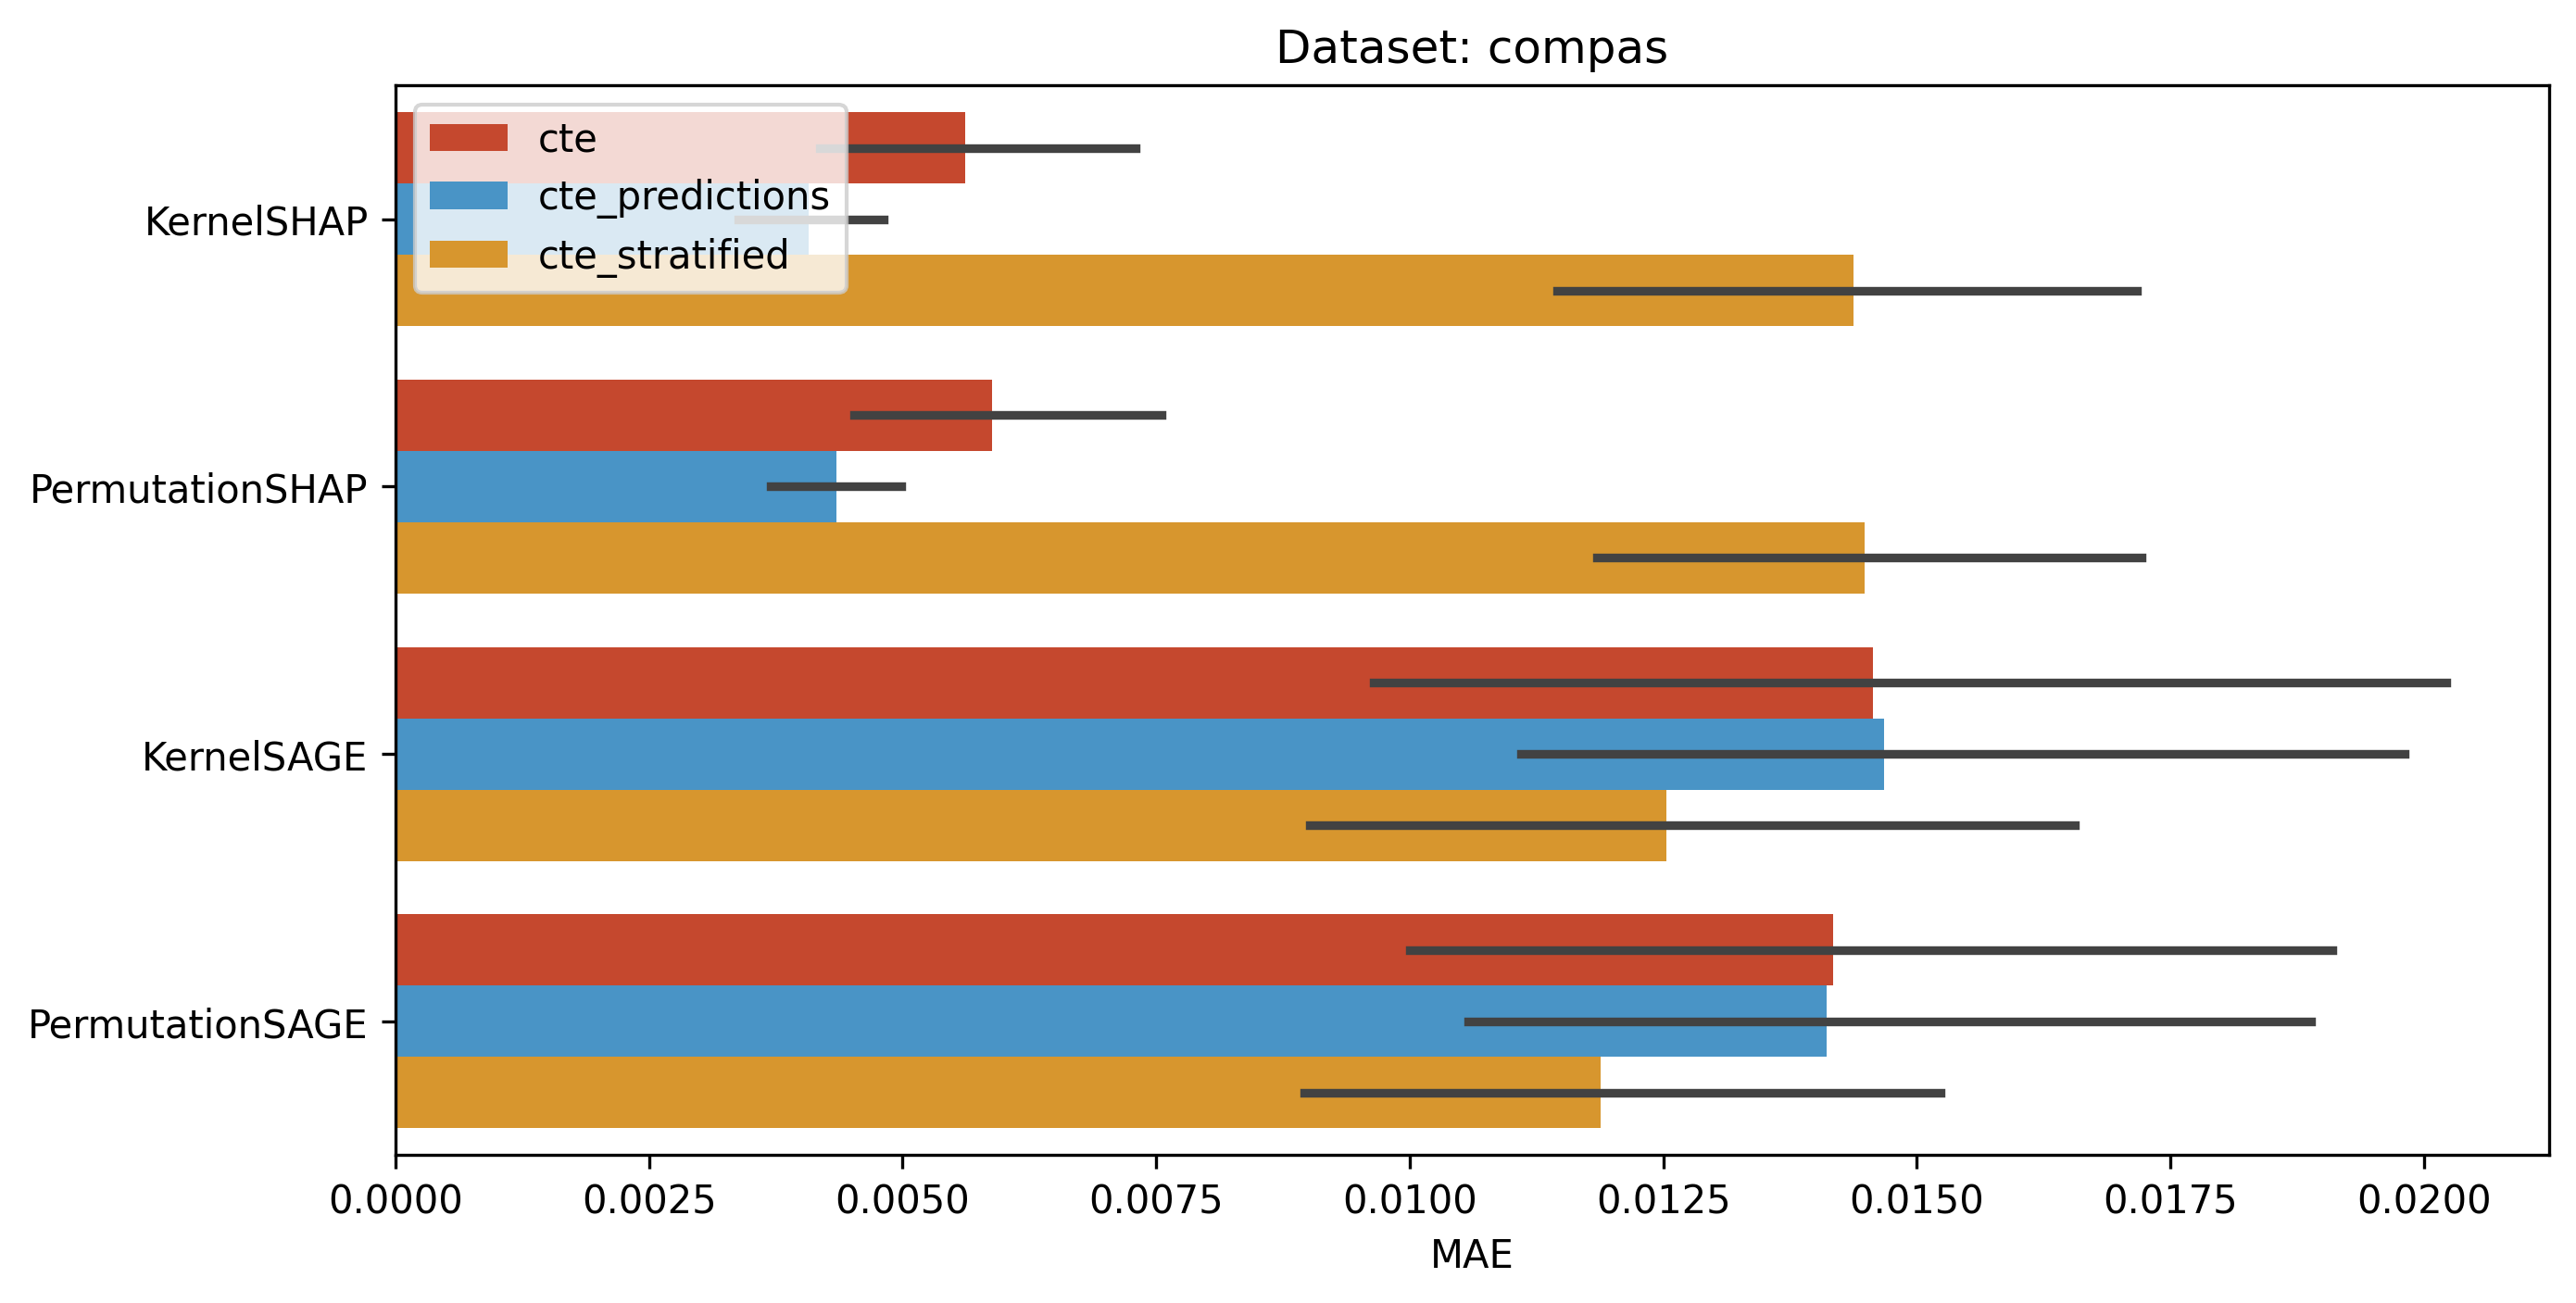

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5), dpi=300)
sns.barplot(y='exp_est', x='mae', hue='method', data=results, palette=['#DE3815', '#3498DB', '#F39C12'])

plt.legend(bbox_to_anchor=(0, 1), loc='upper left')
plt.title("Dataset: " + data_name)
plt.ylabel("") 
plt.xlabel("MAE")
plt.show()
